<a href="https://colab.research.google.com/github/Fatou-Kine3/github_task/blob/main/analysis_of_housing_information.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [6]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [7]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'train.csv', 'sample_data']


In [8]:
import pandas as pd

df = pd.read_csv("/content/train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
## Problem 2 – Analyzing the Dataset

The dataset is the Ames Housing dataset from Kaggle's “House Prices: Advanced Regression Techniques” competition. It contains information about residential properties in Ames, Iowa.

The `train.csv` file contains 1,460 houses and 81 columns. There are 79 explanatory variables describing characteristics such as house size, quality, location, bedrooms, bathrooms, garage, and year built. The target variable is `SalePrice`, which represents the selling price of the house in US dollars.

**Source:** Kaggle – House Prices: Advanced Regression Techniques.

In [ ]:
## Problem 3 – Data Check

First, I check the data types, identify the target variable, and calculate basic statistics.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [10]:
df.describe().loc[["mean", "std", "25%", "50%", "75%"]]

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000


In [ ]:
### Observation

The dataset contains both numerical and categorical variables. `SalePrice` is the target variable. The descriptive statistics show the mean, standard deviation, and quartiles of the numerical features.

In [ ]:
## Problem 4 – Handling Missing Values

First, we check the missing values for each feature.

In [11]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [ ]:
### Missing Value Percentage

In [12]:
missing_ratio = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_ratio
})

missing_table = missing_table[missing_table["Missing Count"] > 0]
missing_table.sort_values("Missing Count", ascending=False)

,Missing Count,Missing Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [13]:
!pip install missingno

In [ ]:
### Removing Columns with 5 or More Missing Values

In [14]:
df_clean = df.copy()

columns_to_drop = df_clean.columns[df_clean.isnull().sum() >= 5]

print("Columns removed:")
print(columns_to_drop.tolist())

df_clean = df_clean.drop(columns=columns_to_drop)

Columns removed:
['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']


In [ ]:
### Removing Rows with Remaining Missing Values

In [15]:
df_clean = df_clean.dropna()

In [16]:
df_clean.isnull().sum().sum()

np.int64(0)

In [ ]:
### Observation

Several columns contained missing values. Columns with 5 or more missing values were removed, and the remaining rows with missing values were also deleted.

This fixed threshold is simple, but it may remove useful information. A different threshold could be more appropriate depending on the dataset.

In [ ]:
## Problem 5 – Terminology Research

### 1. Skewness

**Skewness** measures the asymmetry of a distribution. A value close to 0 indicates a relatively symmetric distribution. A positive value means the distribution has a longer tail on the right, while a negative value means it has a longer tail on the left.

### 2. Kurtosis

**Kurtosis** describes the shape of the tails of a distribution and helps indicate the presence of extreme values or outliers. In the Fisher definition used by Pandas, a normal distribution has a kurtosis of 0.

**Source:** Pandas and SciPy documentation.


In [ ]:
## Problem 6 – Confirming the Distribution

We examine the distribution of `SalePrice`, calculate its skewness and kurtosis, and then apply a logarithmic transformation.

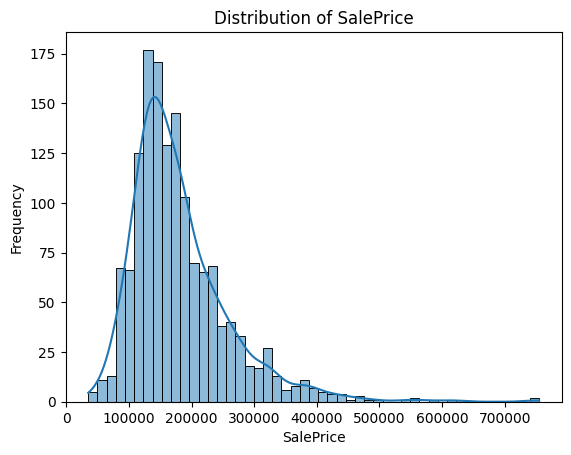

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

In [18]:
print("Skewness:", df["SalePrice"].skew())
print("Kurtosis:", df["SalePrice"].kurtosis())

Skewness: 1.8828757597682129
Kurtosis: 6.536281860064529


In [ ]:
### Logarithmic Transformation

We use `np.log1p()` to transform `SalePrice`.

The function `np.log1p(x)` calculates `log(1 + x)`. It is valid here because `SalePrice` contains positive values. The logarithmic transformation can reduce right skewness and make the distribution more symmetric.

In [19]:
import numpy as np

df["SalePrice_log"] = np.log1p(df["SalePrice"])

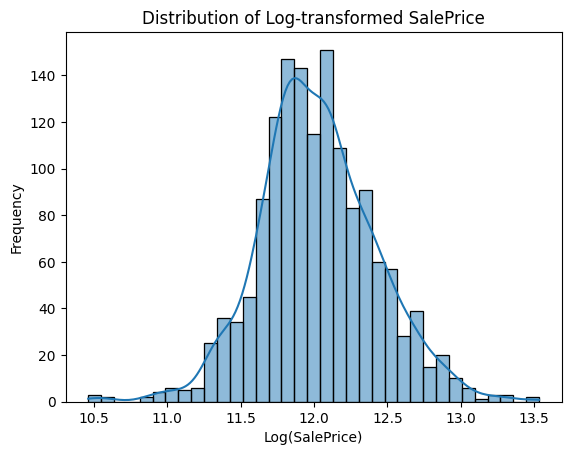

In [20]:
sns.histplot(df["SalePrice_log"], kde=True)
plt.title("Distribution of Log-transformed SalePrice")
plt.xlabel("Log(SalePrice)")
plt.ylabel("Frequency")
plt.show()

In [21]:
print("Skewness after transformation:", df["SalePrice_log"].skew())
print("Kurtosis after transformation:", df["SalePrice_log"].kurtosis())

Skewness after transformation: 0.12134661989685333
Kurtosis after transformation: 0.809519155707878


In [ ]:
### Observation

Before the transformation, `SalePrice` has a right-skewed distribution, with some very high prices.

After applying the logarithmic transformation, the distribution becomes more symmetric and closer to a normal distribution. The skewness is reduced.

A normal distribution is a symmetric, bell-shaped distribution where most values are concentrated around the mean.

The logarithmic transformation can help some statistical or machine learning models, but it does not guarantee better prediction accuracy.

In [ ]:
## Problem 7 – Correlation Coefficient

In [ ]:
### 1. Correlation Matrix of Numerical Features

First, we select the numerical features and calculate their correlation coefficients.

In [22]:
numeric_df = df.select_dtypes(include="number")

corr_matrix = numeric_df.corr()

corr_matrix.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,SalePrice_log
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917,-0.017942
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284,-0.073959
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799,0.355879
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843,0.257320
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982,0.817185


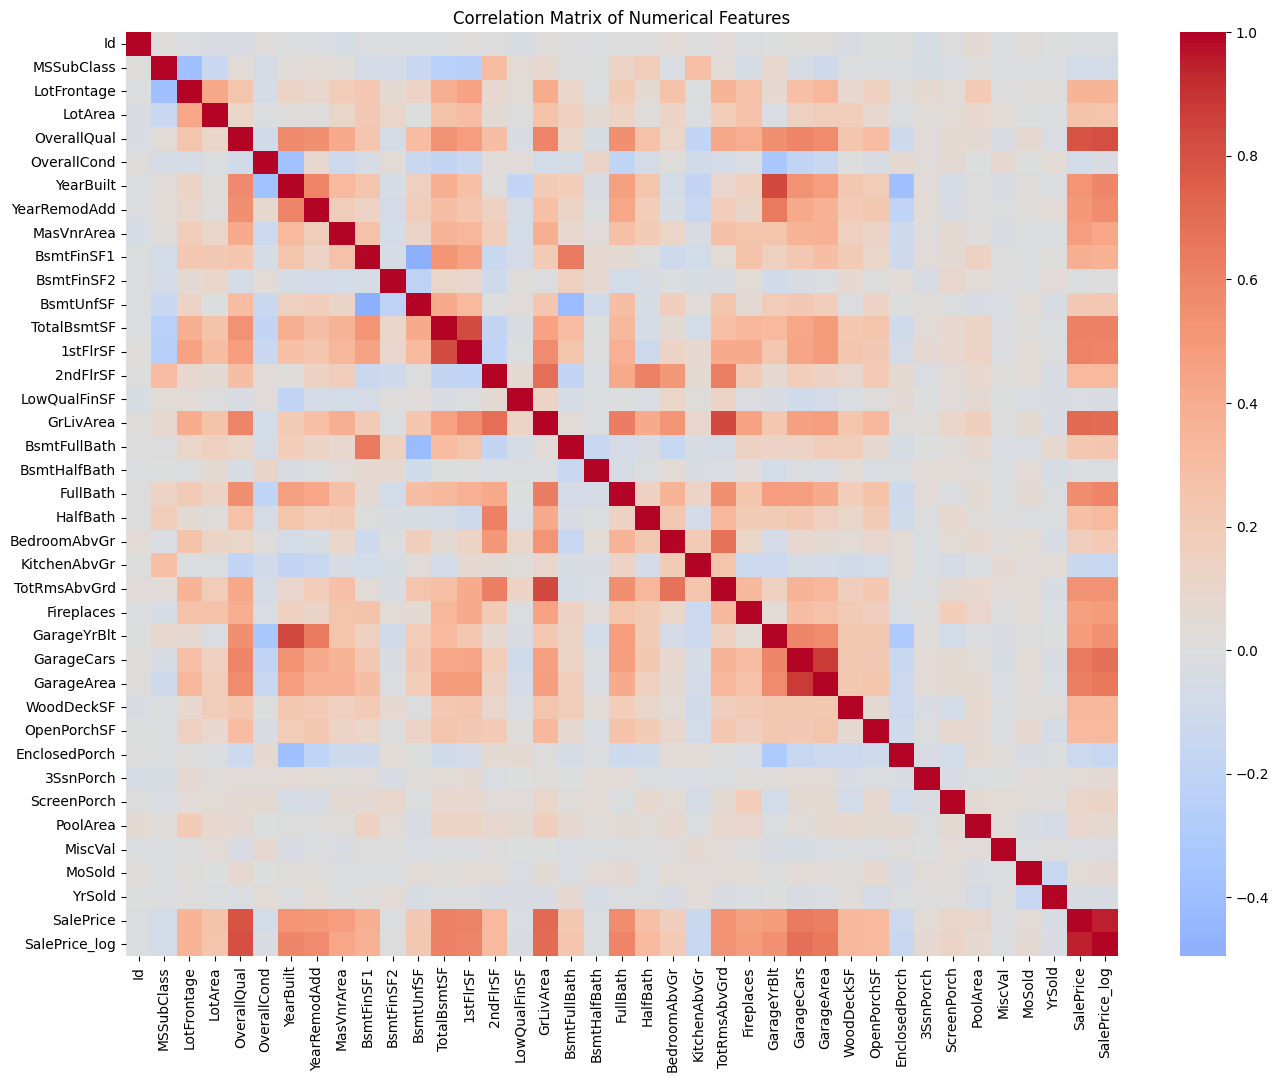

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))

sns.heatmap(corr_matrix, cmap="coolwarm", center=0)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [ ]:
### 2. Strong Correlations

We look for relationships with a high absolute correlation coefficient. A coefficient close to +1 or -1 indicates a strong relationship, while a coefficient close to 0 indicates a weak relationship.

In [24]:
corr_pairs = corr_matrix.abs().unstack()

corr_pairs = corr_pairs[corr_pairs < 1]

corr_pairs.sort_values(ascending=False).head(20)

,,0
SalePrice,SalePrice_log,0.948374
SalePrice_log,SalePrice,0.948374
GarageCars,GarageArea,0.882475
GarageArea,GarageCars,0.882475
GarageYrBlt,YearBuilt,0.825667
YearBuilt,GarageYrBlt,0.825667
GrLivArea,TotRmsAbvGrd,0.825489
TotRmsAbvGrd,GrLivArea,0.825489
TotalBsmtSF,1stFlrSF,0.819530
1stFlrSF,TotalBsmtSF,0.819530


In [ ]:
### 3. Ten Features Highly Correlated with SalePrice

In [25]:
saleprice_corr = numeric_df.corr()["SalePrice"].drop("SalePrice")

top10_features = saleprice_corr.abs().sort_values(ascending=False).head(10)

top10_features

,SalePrice
SalePrice_log,0.948374
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


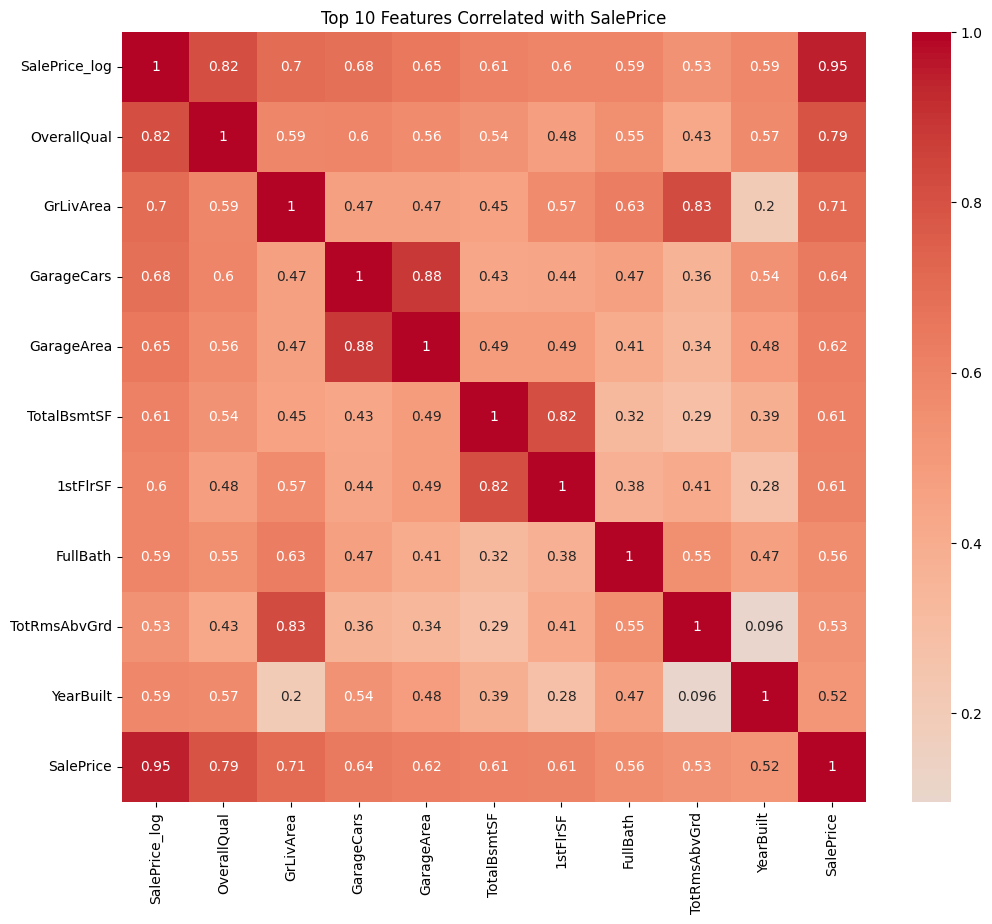

In [26]:
selected_features = top10_features.index.tolist() + ["SalePrice"]

plt.figure(figsize=(12, 10))

sns.heatmap(
    numeric_df[selected_features].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Top 10 Features Correlated with SalePrice")
plt.show()

In [ ]:
### 5. Highly Correlated Feature Pairs

Some of the selected features are also strongly correlated with each other. We identify three highly correlated pairs.

In [27]:
feature_corr = numeric_df[selected_features].corr().drop("SalePrice").drop(columns="SalePrice")

pairs = feature_corr.abs().unstack()

pairs = pairs[pairs < 1].sort_values(ascending=False)

pairs.head(6)

,,0
GarageArea,GarageCars,0.882475
GarageCars,GarageArea,0.882475
GrLivArea,TotRmsAbvGrd,0.825489
TotRmsAbvGrd,GrLivArea,0.825489
TotalBsmtSF,1stFlrSF,0.819530
1stFlrSF,TotalBsmtSF,0.819530


In [ ]:
### Discussion

Some selected features have strong correlations with each other because they describe related aspects of a house. For example, garage capacity and garage area are naturally related.

Strong correlations between explanatory variables can make individual coefficients difficult to interpret in multiple linear regression. However, this does not automatically mean that one variable should be removed. The decision should depend on the model and its validation results.